<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/HCF_vs_SingleCore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/paper/hcf-optimum-launch-power-reproduction/dnanf_fig2_hcf_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# HCF / single-core 선택형 전송 모델 + Figure 4 설계 비교

이 노트북은 기존 **HCF Fig. 2 launch-power 모델**을 보존하면서, 첨부된 SubOptic 2025 논문의 Figure 4 방법과 Python 모델을 통합합니다.

## 새로 추가된 결과

1. `FIBER_MODE = "HCF"`, `"SINGLE_CORE"`, `"ALL"` 중 하나를 선택합니다.
2. 기존과 같은 **launch power–capacity** 그래프를 HCF와 single-core에 대해 계산합니다.
3. 논문 Figure 4처럼 x축을 **fiber length**로 하고 다음 3개 y축을 비교합니다.
   - maximum capacity
   - repeater span length $L_{span}$
   - number of repeaters
4. 12-FP single-core benchmark capacity를 더 많은 FP에 분배하며, PFE 전력·18 dBm·비선형 임계점 대비 2 dB back-off 조건을 적용합니다.

## HCF와 single-core의 입력 분리

- `HollowCoreFiber`: DNANF의 gap, membrane thickness, tube 수, nesting, 파장별 손실·분산 및 IMI를 사용합니다.
- `SingleCoreFiber`: 논문 Table 1의 $\alpha=0.15$ dB/km, $D=-21$ ps/(nm·km), $A_{eff}=110$ μm², $\gamma=0.81$ (W·km)$^{-1}$를 사용합니다. **HCF geometry와 IMI를 호출하지 않습니다.**

> 재현 한계: 첨부 optimizer가 요구하는 EDFA 효율의 원본 2-D lookup table은 논문과 첨부 파일에 포함되지 않았습니다. 따라서 공개 범위 2.0–3.1% 안에서 gain/output-power 기반의 교체 가능한 surrogate를 사용합니다. 정확한 저자 곡선 재현에는 원본 `eta(gain, Pout)` 배열이 추가로 필요합니다.


In [1]:
%pip -q install numpy scipy matplotlib


## 실행 방법과 주요 수정 위치

첫 번째 설정 블록에서 아래 값만 바꾸면 됩니다.

```python
FIBER_MODE = "ALL"  # "HCF", "SINGLE_CORE", "ALL"
FIGURE4_FIBER_LENGTHS_KM = np.arange(6000.0, 15000.1, 500.0)
FIGURE4_FP_COUNTS = (16, 20, 24, 28, 32)
```

- HCF 구조 변경: `DNANFGeometry`
- HCF $\gamma$/IMI 변경: `HollowCoreFiber`
- single-core 스펙 변경: `SingleCoreFiber`
- SubOptic 시스템/PFE 조건 변경: `SubmarineSystem`
- 실제 EDFA 효율 데이터 적용: `edfa_electrical_to_optical_efficiency()` 교체

마지막 `main()` 실행 시 `fig2_hcf_single_core.png`와 `figure4_hcf_vs_single_core.png`가 저장됩니다.


=== Fiber model separation ===
DNANF HCF                                  | alpha=0.0750 dB/km | D=+3.20 ps/(nm km) | gamma=0.0005 1/(W km) | IMI=6.310e-06 1/km
  200-km launch sweep: max=52.671 Tb/s at 22.32 dBm/ch
Single-core silica (SCUBA benchmark)       | alpha=0.1500 dB/km | D=-21.00 ps/(nm km) | gamma=0.81 1/(W km) | IMI=0.000e+00 1/km
  200-km launch sweep: max=46.385 Tb/s at 9.57 dBm/ch

=== Figure-4-style benchmark ===
SC 12-FP target @ 6000 km: 231.15 Tb/s
  HCF         24 FP: sustained    , Lspan=333.3 km, repeaters=18
  SINGLE_CORE 24 FP: sustained    , Lspan=153.8 km, repeaters=39
SC 12-FP target @ 11000 km: 188.22 Tb/s
  HCF         24 FP: sustained    , Lspan=323.5 km, repeaters=34
  SINGLE_CORE 24 FP: sustained    , Lspan=139.2 km, repeaters=79
SC 12-FP target @ 15000 km: 133.84 Tb/s
  HCF         24 FP: sustained    , Lspan=340.9 km, repeaters=44
  SINGLE_CORE 24 FP: sustained    , Lspan=106.4 km, repeaters=141


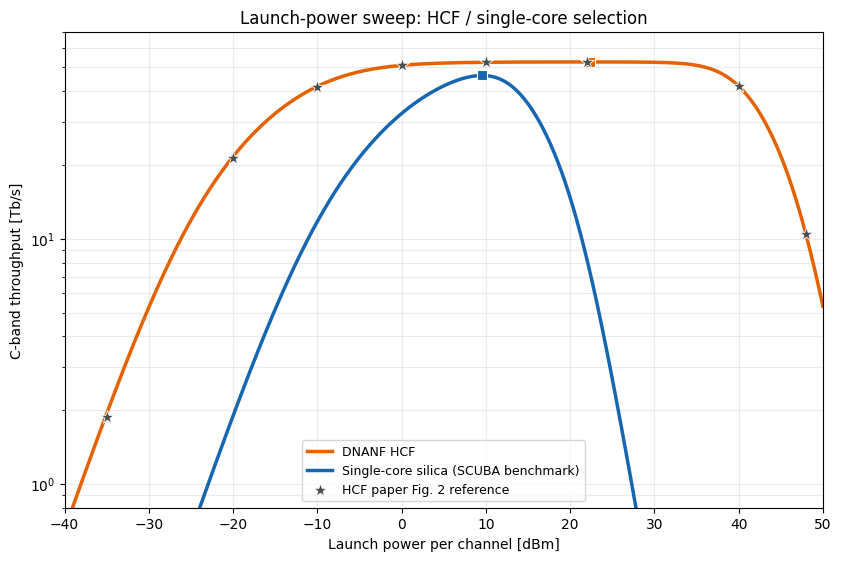

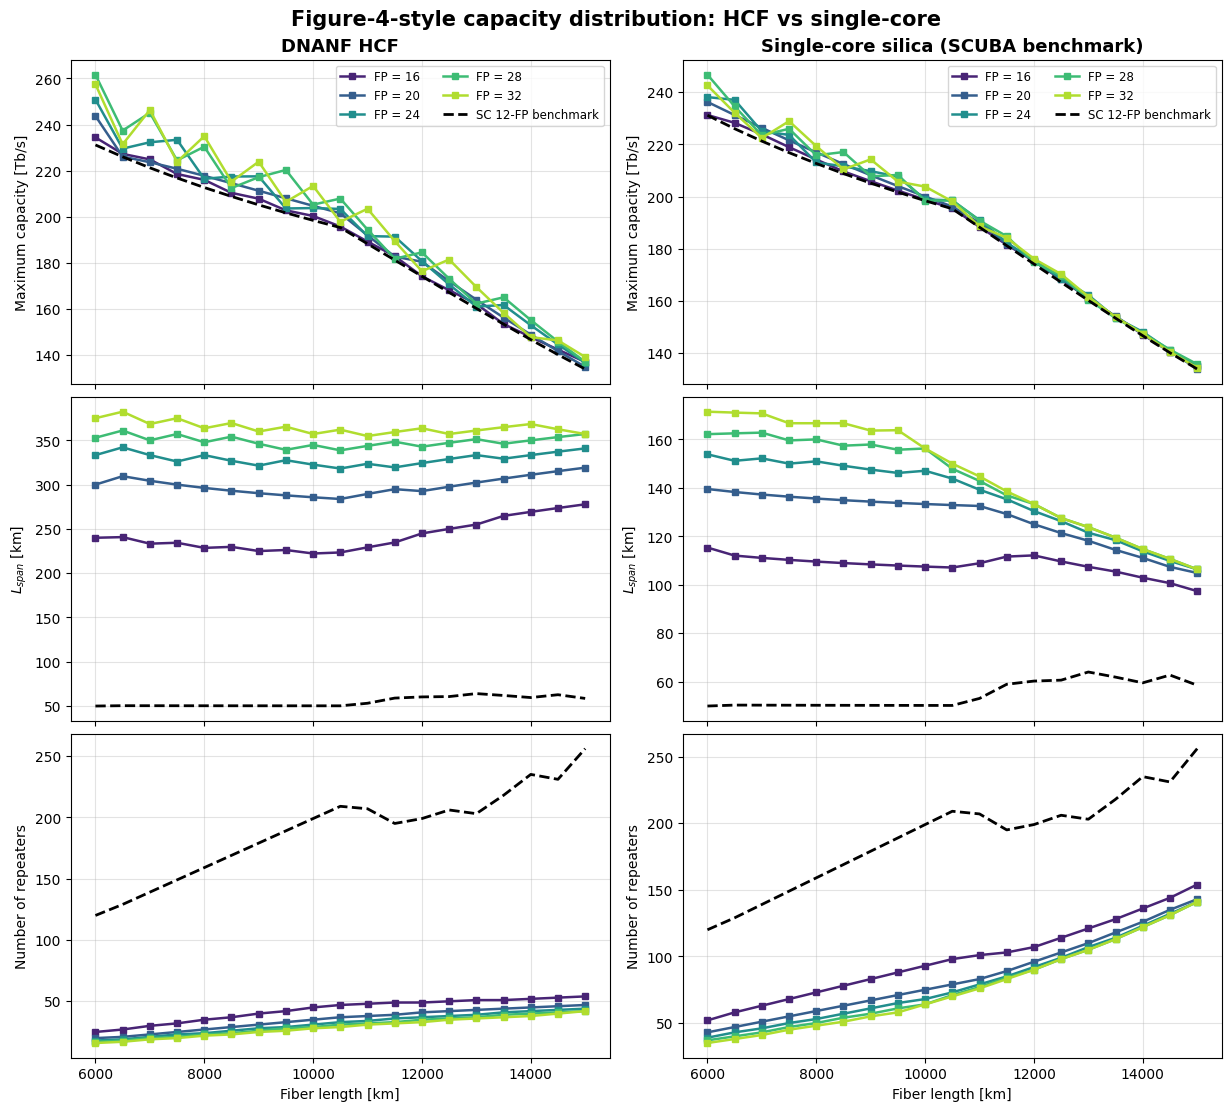

In [2]:
"""Colab-ready HCF / single-core transmission and Figure 4 design model.

The file has two independent studies:

1. A launch-power sweep compatible with the original Fig. 2 HCF notebook.
2. A SubOptic-2025-Fig.-4-style submarine design sweep versus fibre length.

HCF-only geometry and intermodal-interference (IMI) parameters live in
``HollowCoreFiber``.  ``SingleCoreFiber`` never constructs or accesses a
DNANF geometry and returns zero IMI by construction.
"""

from __future__ import annotations

from dataclasses import dataclass
from enum import Enum
from functools import lru_cache
from pathlib import Path
from typing import Protocol

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares


C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
U01 = 2.4048255577
DB_PER_NEPER = 10.0 / np.log(10.0)


# =============================================================================
# 0) User controls
# =============================================================================

# "HCF", "SINGLE_CORE", or "ALL"
FIBER_MODE = "ALL"

# Figure-4-style comparison controls.
FIGURE4_FIBER_LENGTHS_KM = np.arange(6000.0, 15000.1, 500.0)
FIGURE4_FP_COUNTS = (16, 20, 24, 28, 32)


class FiberKind(str, Enum):
    HCF = "HCF"
    SINGLE_CORE = "SINGLE_CORE"


@dataclass(frozen=True)
class OpticalParameters:
    attenuation_db_per_km: np.ndarray
    dispersion_ps_nm_km: np.ndarray


class FiberModel(Protocol):
    """Common interface; it deliberately contains no geometry fields."""

    kind: FiberKind
    label: str
    nonlinear_coefficient_per_w_km: float

    def optical_parameters(self, wavelength_m: np.ndarray) -> OpticalParameters:
        ...

    @property
    def imi_linear_per_km(self) -> float:
        ...


# =============================================================================
# 1) HCF-only DNANF geometry and wavelength-dependent optical model
# =============================================================================


@dataclass(frozen=True)
class DNANFGeometry:
    """HCF-only geometry.  Single-core fibre does not instantiate this class."""

    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self) -> float:
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self) -> float:
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self) -> float:
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


def silica_index_sellmeier(wavelength_m: np.ndarray) -> np.ndarray:
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi * wavelength_um_sq / (wavelength_um_sq - ci**2)
    return np.sqrt(n_sq)


def hasan_radius_coefficients(geometry: DNANFGeometry) -> tuple[float, float]:
    radius_to_gap = geometry.core_radius_m / geometry.perimeter_gap_m
    n = geometry.tube_count
    nesting = geometry.nesting_order
    a0, a1 = 0.097041, 1.095
    b0, b1, b2, b3 = 0.76246, 0.007584, 0.002, 0.012
    f1 = a1 * np.exp(a0 / radius_to_gap)
    f2 = (
        b1 * n * np.exp(b0 / radius_to_gap)
        - b2 * n
        + b3
        + 0.0045 * np.exp(-4.1589 / (nesting * radius_to_gap))
    )
    return float(f1), float(f2)


def hcf_effective_index(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    effective_radius = f1 * radius * (
        1.0 - f2 * wavelength_m**2 / (radius * wall)
    )
    return 1.0 - 0.125 * (U01 * wavelength_m / (np.pi * effective_radius)) ** 2


def hcf_dispersion_ps_nm_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
    f1: float,
    f2: float,
    derivative_step_nm: float = 0.20,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    step = derivative_step_nm * 1e-9

    def n_eff(offset: float) -> np.ndarray:
        return hcf_effective_index(wavelength_m + offset, geometry, f1, f2)

    second_derivative = (
        -n_eff(2.0 * step)
        + 16.0 * n_eff(step)
        - 30.0 * n_eff(0.0)
        + 16.0 * n_eff(-step)
        - n_eff(-2.0 * step)
    ) / (12.0 * step**2)
    dispersion_si = -(wavelength_m / C0) * second_derivative
    return dispersion_si / 1e-6


@lru_cache(maxsize=None)
def calibrate_hcf_dispersion(geometry: DNANFGeometry) -> tuple[float, float]:
    reference_nm = np.array([1310.0, 1550.0])
    reference_d = np.array([2.17, 3.20])
    initial = np.array(hasan_radius_coefficients(geometry))

    def residual(parameters: np.ndarray) -> np.ndarray:
        return hcf_dispersion_ps_nm_km(
            reference_nm * 1e-9, geometry, parameters[0], parameters[1]
        ) - reference_d

    result = least_squares(
        residual,
        x0=initial,
        bounds=(np.array([0.5, -0.5]), np.array([2.5, 1.0])),
        x_scale="jac",
        diff_step=1e-3,
        xtol=1e-13,
        ftol=1e-13,
        gtol=1e-13,
    )
    if not result.success or np.max(np.abs(result.fun)) > 1e-3:
        raise RuntimeError(f"HCF dispersion calibration failed: {result.fun}")
    return float(result.x[0]), float(result.x[1])


def capillary_bouncing_ray_loss_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2.0 * np.pi / wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01 / radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0 * np.sqrt(silica_n**2 - 1.0)
    phase = sigma * wall
    te_denominator = 4.0 * np.cos(phase) ** 2 + (
        kappa / sigma + sigma / kappa
    ) ** 2 * np.sin(phase) ** 2
    tm_denominator = 4.0 * np.cos(phase) ** 2 + (
        silica_n**2 * kappa / sigma + sigma / (silica_n**2 * kappa)
    ) ** 2 * np.sin(phase) ** 2
    alpha_te_per_m = 2.0 * U01 / (radius**2 * k0 * te_denominator)
    alpha_tm_per_m = 2.0 * U01 / (radius**2 * k0 * tm_denominator)
    return 0.5 * (alpha_te_per_m + alpha_tm_per_m) * DB_PER_NEPER * 1000.0


def hcf_attenuation_db_km(
    wavelength_m: np.ndarray,
    geometry: DNANFGeometry,
) -> np.ndarray:
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    reference_alpha = np.array([0.075, 0.120])
    lambda_ref_m = reference_nm[0] * 1e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm * 1e-9, geometry)
    basis_reference = np.column_stack(
        [
            (lambda_ref_m / (reference_nm * 1e-9)) ** 3,
            (br_ref / br_ref[0]) ** 2,
        ]
    )
    a_surface, a_nested = np.linalg.solve(basis_reference, reference_alpha)
    if a_surface < 0.0 or a_nested < 0.0:
        raise RuntimeError("Calibrated HCF attenuation terms must be non-negative.")
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    return (
        a_surface * (lambda_ref_m / wavelength_m) ** 3
        + a_nested * (br / br_ref[0]) ** 2
    )


@dataclass(frozen=True)
class HollowCoreFiber:
    """DNANF HCF: geometry and IMI are meaningful for this model only."""

    kind: FiberKind = FiberKind.HCF
    label: str = "DNANF HCF"
    geometry: DNANFGeometry = DNANFGeometry()
    nonlinear_coefficient_per_w_km: float = 5e-4
    imi_coefficient_db_per_km: float = -52.0

    def optical_parameters(self, wavelength_m: np.ndarray) -> OpticalParameters:
        f1, f2 = calibrate_hcf_dispersion(self.geometry)
        return OpticalParameters(
            attenuation_db_per_km=hcf_attenuation_db_km(wavelength_m, self.geometry),
            dispersion_ps_nm_km=hcf_dispersion_ps_nm_km(
                wavelength_m, self.geometry, f1, f2
            ),
        )

    @property
    def imi_linear_per_km(self) -> float:
        return 10.0 ** (self.imi_coefficient_db_per_km / 10.0)


@dataclass(frozen=True)
class SingleCoreFiber:
    """SubOptic 2025 Table-1 SCUBA single-core benchmark parameters.

    No HCF geometry and no IMI/crosstalk term are present in this class.
    """

    kind: FiberKind = FiberKind.SINGLE_CORE
    label: str = "Single-core silica (SCUBA benchmark)"
    attenuation_db_per_km: float = 0.15
    dispersion_ps_nm_km: float = -21.0
    effective_area_um2: float = 110.0
    nonlinear_coefficient_per_w_km: float = 0.81

    def optical_parameters(self, wavelength_m: np.ndarray) -> OpticalParameters:
        shape = np.asarray(wavelength_m, dtype=float).shape
        return OpticalParameters(
            attenuation_db_per_km=np.full(shape, self.attenuation_db_per_km),
            dispersion_ps_nm_km=np.full(shape, self.dispersion_ps_nm_km),
        )

    @property
    def imi_linear_per_km(self) -> float:
        return 0.0


def selected_fibers(mode: str = FIBER_MODE) -> list[FiberModel]:
    key = mode.strip().upper()
    if key == FiberKind.HCF.value:
        return [HollowCoreFiber()]
    if key in {FiberKind.SINGLE_CORE.value, "SC", "SINGLE-CORE"}:
        return [SingleCoreFiber()]
    if key == "ALL":
        return [HollowCoreFiber(), SingleCoreFiber()]
    raise ValueError("FIBER_MODE must be 'HCF', 'SINGLE_CORE', or 'ALL'.")


def beta2_s2_per_km(
    dispersion_ps_nm_km: np.ndarray,
    wavelength_m: np.ndarray,
) -> np.ndarray:
    dispersion_si = np.asarray(dispersion_ps_nm_km) * 1e-6
    beta2_s2_per_m = -(
        np.asarray(wavelength_m) ** 2 / (2.0 * np.pi * C0)
    ) * dispersion_si
    return beta2_s2_per_m * 1000.0


# =============================================================================
# 2) Original-notebook-compatible launch-power sweep
# =============================================================================


@dataclass(frozen=True)
class LaunchSweepConfig:
    n_channels: int = 29
    symbol_rate_gbd: float = 140.0
    channel_spacing_ghz: float = 150.0
    c_band_min_nm: float = 1530.0
    c_band_max_nm: float = 1565.0
    span_length_km: float = 200.0
    n_spans: int = 1
    amplifier_noise_figure_db: float = 5.0
    transceiver_snr_db: float = 20.0

    @property
    def symbol_rate_hz(self) -> float:
        return self.symbol_rate_gbd * 1e9

    @property
    def channel_spacing_hz(self) -> float:
        return self.channel_spacing_ghz * 1e9

    @property
    def total_length_km(self) -> float:
        return self.span_length_km * self.n_spans


PAPER_HCF_LAUNCH_DBM = np.array([-35.0, -20.0, -10.0, 0.0, 10.0, 22.0, 40.0, 48.0])
PAPER_HCF_THROUGHPUT_TBPS = np.array(
    [1.87292462, 21.32203450, 41.62572367, 50.95120740,
     52.49881133, 52.67046429, 42.03103403, 10.44268748]
)


def c_band_grid(config: LaunchSweepConfig) -> tuple[np.ndarray, np.ndarray]:
    lower_hz = C0 / (config.c_band_max_nm * 1e-9)
    upper_hz = C0 / (config.c_band_min_nm * 1e-9)
    center_hz = 0.5 * (lower_hz + upper_hz)
    offsets = np.arange(config.n_channels) - 0.5 * (config.n_channels - 1)
    frequency_hz = center_hz + offsets * config.channel_spacing_hz
    wavelength_m = C0 / frequency_hz
    if frequency_hz[0] < lower_hz or frequency_hz[-1] > upper_hz:
        raise ValueError("The WDM grid does not fit inside the selected band.")
    return frequency_hz, wavelength_m


def closed_form_gn_eta(
    beta2: np.ndarray,
    attenuation_db_per_km: np.ndarray,
    fiber: FiberModel,
    config: LaunchSweepConfig,
) -> np.ndarray:
    beta2_abs = np.maximum(np.abs(np.asarray(beta2, dtype=float)), 1e-30)
    alpha_field = np.asarray(attenuation_db_per_km) / 8.685889638
    rate = config.symbol_rate_hz
    spacing = config.channel_spacing_hz
    argument = (
        np.pi**2 * beta2_abs * rate**2 / (4.0 * alpha_field)
        * config.n_channels ** (2.0 * rate / spacing)
    )
    return (
        config.n_spans
        * 4.0
        * fiber.nonlinear_coefficient_per_w_km**2
        / (27.0 * np.pi * beta2_abs * alpha_field * rate**2)
        * np.arcsinh(argument)
    )


def simulate_launch_sweep(
    fiber: FiberModel,
    launch_dbm: np.ndarray,
    config: LaunchSweepConfig = LaunchSweepConfig(),
) -> dict[str, np.ndarray | float | str]:
    launch_dbm = np.asarray(launch_dbm, dtype=float)
    frequency_hz, wavelength_m = c_band_grid(config)
    optical = fiber.optical_parameters(wavelength_m)
    beta2 = beta2_s2_per_km(optical.dispersion_ps_nm_km, wavelength_m)
    eta = closed_form_gn_eta(
        beta2, optical.attenuation_db_per_km, fiber, config
    )
    span_gain = 10.0 ** (
        optical.attenuation_db_per_km * config.span_length_km / 10.0
    )
    noise_factor = 10.0 ** (config.amplifier_noise_figure_db / 10.0)
    ase_w = (
        config.n_spans * H_PLANCK * frequency_hz * noise_factor
        * config.symbol_rate_hz * (span_gain - 1.0)
    )

    launch_w = 10.0 ** ((launch_dbm - 30.0) / 10.0)
    signal = launch_w[:, None]
    nonlinear = eta[None, :] * signal**3
    imi = signal * fiber.imi_linear_per_km * config.total_length_km
    transceiver = signal / (10.0 ** (config.transceiver_snr_db / 10.0))
    snr = signal / (ase_w[None, :] + nonlinear + imi + transceiver)
    throughput = 2.0 * config.symbol_rate_hz * np.log2(1.0 + snr)
    total_tbps = throughput.sum(axis=1) / 1e12
    optimum = int(np.argmax(total_tbps))
    return {
        "fiber": fiber.label,
        "launch_dbm": launch_dbm,
        "total_throughput_tbps": total_tbps,
        "snr_linear": snr,
        "attenuation_db_km": optical.attenuation_db_per_km,
        "dispersion_ps_nm_km": optical.dispersion_ps_nm_km,
        "eta_per_w2": eta,
        "optimum_index": optimum,
        "optimum_launch_dbm": float(launch_dbm[optimum]),
        "maximum_throughput_tbps": float(total_tbps[optimum]),
    }


def plot_launch_sweeps(
    fibers: list[FiberModel],
    output_path: Path | str = "fig2_hcf_single_core.png",
) -> tuple[dict[str, dict[str, np.ndarray | float | str]], plt.Figure]:
    launch_dbm = np.linspace(-40.0, 50.0, 1201)
    results = {
        fiber.kind.value: simulate_launch_sweep(fiber, launch_dbm)
        for fiber in fibers
    }
    colors = {FiberKind.HCF.value: "#e66100", FiberKind.SINGLE_CORE.value: "#1666b1"}
    fig, ax = plt.subplots(figsize=(8.3, 5.5), constrained_layout=True)
    for fiber in fibers:
        result = results[fiber.kind.value]
        curve = np.asarray(result["total_throughput_tbps"])
        optimum = int(result["optimum_index"])
        ax.plot(launch_dbm, curve, lw=2.5, color=colors[fiber.kind.value], label=fiber.label)
        ax.plot(launch_dbm[optimum], curve[optimum], "s", ms=7,
                color=colors[fiber.kind.value], mec="white", mew=0.8)
    if FiberKind.HCF.value in results:
        ax.scatter(PAPER_HCF_LAUNCH_DBM, PAPER_HCF_THROUGHPUT_TBPS,
                   marker="*", s=105, color="#4d4d4d", edgecolors="white",
                   linewidths=0.6, label="HCF paper Fig. 2 reference", zorder=5)
    ax.set_yscale("log")
    ax.set_xlim(-40, 50)
    ax.set_ylim(0.8, 70)
    ax.set_xlabel("Launch power per channel [dBm]")
    ax.set_ylabel("C-band throughput [Tb/s]")
    ax.set_title("Launch-power sweep: HCF / single-core selection")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(fontsize=9)
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return results, fig


# =============================================================================
# 3) Generalized-droop / PFE model used for the Figure-4-style comparison
# =============================================================================


@dataclass(frozen=True)
class SubmarineSystem:
    """SubOptic 2025 Table-1 system assumptions."""

    noise_figure_db: float = 4.5
    circuit_fraction: float = 0.10
    pfe_voltage_v: float = 18_000.0
    conductor_resistance_ohm_per_km: float = 1.0
    bandwidth_hz: float = 4.3e12
    symbol_rate_hz: float = 100e9
    channel_spacing_hz: float = 112.5e9
    center_wavelength_nm: float = 1550.0
    maximum_amplifier_output_dbm: float = 18.0
    nonlinear_backoff_db: float = 2.0
    transceiver_snr_db: float | None = None

    @property
    def n_channels(self) -> int:
        return int(np.floor(self.bandwidth_hz / self.channel_spacing_hz))


@dataclass(frozen=True)
class DesignPoint:
    total_length_km: float
    span_length_km: float
    repeaters: int
    fiber_pairs: int
    maximum_capacity_tbps: float
    snr_linear: float
    launch_power_dbm: float
    power_limiter: str


@lru_cache(maxsize=None)
def center_fiber_parameters(fiber: FiberModel) -> tuple[float, float, float]:
    """Cache alpha, D, and beta2 because the design sweep reuses 1550 nm."""

    wavelength_m = 1550e-9
    optical = fiber.optical_parameters(np.array([wavelength_m]))
    alpha_db = float(optical.attenuation_db_per_km[0])
    dispersion = float(optical.dispersion_ps_nm_km[0])
    beta2 = float(
        abs(beta2_s2_per_km(np.array([dispersion]), np.array([wavelength_m]))[0])
    )
    return alpha_db, dispersion, beta2


def edfa_electrical_to_optical_efficiency(
    gain_db: float,
    total_output_power_w: np.ndarray,
) -> np.ndarray:
    """Replaceable surrogate for the paper's unpublished 2-D EDFA table.

    The paper only discloses a 2.0--3.1% range, while the attached optimizer
    expects eta(gain, output power).  This bounded interpolation preserves that
    range and can be replaced directly with measured/vendor lookup data.
    """

    output_w = np.maximum(np.asarray(total_output_power_w, dtype=float), 1e-12)
    output_dbm = 10.0 * np.log10(output_w) + 30.0
    # Low-gain / low-output EDFAs sit close to the disclosed 2% floor;
    # efficiency approaches 3.1% only when both gain and output are high.
    gain_term = np.clip((gain_db - 7.0) / 5.0, 0.0, 1.0)
    output_term = np.clip((output_dbm - 5.0) / 13.0, 0.0, 1.0) ** 2
    return 0.020 + 0.011 * gain_term * output_term


def generalized_droop_snr(
    total_launch_power_w: np.ndarray,
    total_length_km: float,
    repeaters: int,
    fiber: FiberModel,
    system: SubmarineSystem,
) -> np.ndarray:
    """Equations (2)--(5) of the attached SubOptic paper.

    For HCF, the same redistribution-droop position is used for IMI.  For
    single-core fibre ``imi_linear_per_km`` is exactly zero.
    """

    power_w = np.maximum(np.asarray(total_launch_power_w, dtype=float), 1e-18)
    wavelength_m = system.center_wavelength_nm * 1e-9
    if system.center_wavelength_nm == 1550.0:
        alpha_db, dispersion, beta2 = center_fiber_parameters(fiber)
    else:
        optical = fiber.optical_parameters(np.array([wavelength_m]))
        alpha_db = float(optical.attenuation_db_per_km[0])
        dispersion = float(optical.dispersion_ps_nm_km[0])
        beta2 = float(
            abs(beta2_s2_per_km(np.array([dispersion]), np.array([wavelength_m]))[0])
        )
    span_length_km = total_length_km / repeaters
    n_channels = system.n_channels
    power_per_channel = power_w / n_channels

    alpha_power_per_km = alpha_db / 4.343
    span_gain_db = alpha_db * span_length_km
    gain_linear = 10.0 ** (span_gain_db / 10.0)
    noise_factor = 10.0 ** (system.noise_figure_db / 10.0)
    optical_frequency_hz = C0 / wavelength_m
    pase = (
        H_PLANCK * optical_frequency_hz * noise_factor * system.symbol_rate_hz
        * (gain_linear - 1.0)
    )
    chi_a_inverse = 1.0 + pase / power_per_channel

    leff = (1.0 - np.exp(-alpha_power_per_km * span_length_km)) / alpha_power_per_km
    leff_asymptotic = 1.0 / alpha_power_per_km
    asinh_argument = (
        np.pi**2 / 2.0 * beta2 * leff_asymptotic * system.symbol_rate_hz**2
        * n_channels ** (2.0 * system.symbol_rate_hz / system.channel_spacing_hz)
    )
    alpha_nli = (
        8.0 / 27.0 * fiber.nonlinear_coefficient_per_w_km**2 * leff**2
        * np.arcsinh(asinh_argument)
        / (np.pi * beta2 * leff_asymptotic * system.symbol_rate_hz**2)
    )
    inverse_snr_one_repeater = alpha_nli * power_per_channel**2
    inverse_snr_one_repeater += fiber.imi_linear_per_km * span_length_km
    chi_r_inverse = 1.0 + inverse_snr_one_repeater

    log_accumulated_factor = repeaters * (
        np.log(chi_a_inverse) + np.log(chi_r_inverse)
    )
    link_snr = 1.0 / np.expm1(np.minimum(log_accumulated_factor, 700.0))
    if system.transceiver_snr_db is not None:
        trx_snr = 10.0 ** (system.transceiver_snr_db / 10.0)
        link_snr = 1.0 / (1.0 / link_snr + 1.0 / trx_snr)
    return link_snr


def operating_point(
    total_length_km: float,
    repeaters: int,
    fiber_pairs: int,
    fiber: FiberModel,
    system: SubmarineSystem,
) -> DesignPoint:
    """Maximize GSNR under PFE, NL-backoff, and 18-dBm constraints."""

    power_dbm = np.linspace(-30.0, 20.0, 1001)
    power_w = 10.0 ** ((power_dbm - 30.0) / 10.0)
    snr_unconstrained = generalized_droop_snr(
        power_w, total_length_km, repeaters, fiber, system
    )
    nonlinear_threshold_w = power_w[int(np.argmax(snr_unconstrained))]
    nonlinear_guard_w = nonlinear_threshold_w / (
        10.0 ** (system.nonlinear_backoff_db / 10.0)
    )
    hard_output_cap_w = 10.0 ** (
        (system.maximum_amplifier_output_dbm - 30.0) / 10.0
    )

    span_length_km = total_length_km / repeaters
    if system.center_wavelength_nm == 1550.0:
        alpha_db = center_fiber_parameters(fiber)[0]
    else:
        wavelength_m = system.center_wavelength_nm * 1e-9
        alpha_db = float(
            fiber.optical_parameters(np.array([wavelength_m])).attenuation_db_per_km[0]
        )
    gain_db = alpha_db * span_length_km
    eta_eo = edfa_electrical_to_optical_efficiency(gain_db, power_w)
    pfe_cap_w = (
        system.pfe_voltage_v**2
        * (1.0 - system.circuit_fraction)
        * eta_eo
        / (
            4.0 * system.conductor_resistance_ohm_per_km * total_length_km
            * repeaters * 2.0 * fiber_pairs
        )
    )
    feasible = (
        (power_w <= pfe_cap_w)
        & (power_w <= nonlinear_guard_w)
        & (power_w <= hard_output_cap_w)
    )
    if not np.any(feasible):
        feasible[0] = True
    feasible_indices = np.flatnonzero(feasible)
    chosen = feasible_indices[int(np.argmax(snr_unconstrained[feasible]))]
    snr = float(snr_unconstrained[chosen])
    capacity_tbps = (
        fiber_pairs * system.n_channels * system.symbol_rate_hz
        * np.log2(1.0 + snr) / 1e12
    )

    caps = {
        "PFE": float(pfe_cap_w[chosen]),
        "NL - 2 dB": float(nonlinear_guard_w),
        "18 dBm": float(hard_output_cap_w),
    }
    limiter = min(caps, key=caps.get)
    return DesignPoint(
        total_length_km=float(total_length_km),
        span_length_km=float(span_length_km),
        repeaters=int(repeaters),
        fiber_pairs=int(fiber_pairs),
        maximum_capacity_tbps=float(capacity_tbps),
        snr_linear=snr,
        launch_power_dbm=float(power_dbm[chosen]),
        power_limiter=limiter,
    )


def enumerate_designs(
    total_length_km: float,
    fiber_pairs: int,
    fiber: FiberModel,
    system: SubmarineSystem,
    minimum_span_km: float,
    maximum_span_km: float,
) -> list[DesignPoint]:
    minimum_repeaters = max(1, int(np.ceil(total_length_km / maximum_span_km)))
    maximum_repeaters = max(minimum_repeaters, int(np.floor(total_length_km / minimum_span_km)))
    return [
        operating_point(total_length_km, nrep, fiber_pairs, fiber, system)
        for nrep in range(minimum_repeaters, maximum_repeaters + 1)
    ]


def benchmark_single_core(
    total_length_km: float,
    system: SubmarineSystem,
) -> DesignPoint:
    """Paper benchmark: highest SC 12-FP capacity with span >= 50 km."""

    points = enumerate_designs(
        total_length_km, 12, SingleCoreFiber(), system,
        minimum_span_km=50.0, maximum_span_km=250.0,
    )
    return max(points, key=lambda point: point.maximum_capacity_tbps)


def distribute_benchmark_capacity(
    total_length_km: float,
    target_capacity_tbps: float,
    fiber_pairs: int,
    fiber: FiberModel,
    system: SubmarineSystem,
) -> tuple[DesignPoint, bool]:
    """Choose the longest span that can carry the SC-12 benchmark capacity."""

    points = enumerate_designs(
        total_length_km, fiber_pairs, fiber, system,
        minimum_span_km=40.0, maximum_span_km=450.0,
    )
    sustainable = [
        point for point in points
        if point.maximum_capacity_tbps >= target_capacity_tbps
    ]
    if sustainable:
        return min(sustainable, key=lambda point: point.repeaters), True
    return max(points, key=lambda point: point.maximum_capacity_tbps), False


def run_figure4_study(
    fibers: list[FiberModel],
    lengths_km: np.ndarray = FIGURE4_FIBER_LENGTHS_KM,
    fp_counts: tuple[int, ...] = FIGURE4_FP_COUNTS,
    system: SubmarineSystem = SubmarineSystem(),
) -> dict[str, object]:
    lengths = np.asarray(lengths_km, dtype=float)
    benchmarks = [benchmark_single_core(length, system) for length in lengths]
    target_capacity = np.array([p.maximum_capacity_tbps for p in benchmarks])
    benchmark_span = np.array([p.span_length_km for p in benchmarks])
    benchmark_repeaters = np.array([p.repeaters for p in benchmarks])

    cases: dict[str, dict[int, dict[str, np.ndarray]]] = {}
    for fiber in fibers:
        fiber_cases: dict[int, dict[str, np.ndarray]] = {}
        for fp in fp_counts:
            chosen_points: list[DesignPoint] = []
            sustained: list[bool] = []
            for length, target in zip(lengths, target_capacity):
                point, ok = distribute_benchmark_capacity(
                    length, target, fp, fiber, system
                )
                chosen_points.append(point)
                sustained.append(ok)
            ok_array = np.asarray(sustained, dtype=bool)
            maximum_capacity = np.array(
                [p.maximum_capacity_tbps for p in chosen_points]
            )
            # Delivered capacity is capped at the benchmark service target.
            delivered_capacity = np.where(
                ok_array, target_capacity, maximum_capacity
            )
            fiber_cases[fp] = {
                "capacity_tbps": delivered_capacity,
                "maximum_capacity_tbps": maximum_capacity,
                "span_length_km": np.where(
                    ok_array, [p.span_length_km for p in chosen_points], np.nan
                ),
                "repeaters": np.where(
                    ok_array, [p.repeaters for p in chosen_points], np.nan
                ),
                "launch_power_dbm": np.array(
                    [p.launch_power_dbm for p in chosen_points]
                ),
                "sustained": ok_array,
            }
        cases[fiber.kind.value] = fiber_cases

    return {
        "lengths_km": lengths,
        "target_capacity_tbps": target_capacity,
        "benchmark_span_length_km": benchmark_span,
        "benchmark_repeaters": benchmark_repeaters,
        "cases": cases,
    }


def plot_figure4_study(
    study: dict[str, object],
    fibers: list[FiberModel],
    fp_counts: tuple[int, ...] = FIGURE4_FP_COUNTS,
    output_path: Path | str = "figure4_hcf_vs_single_core.png",
) -> plt.Figure:
    """Three-row Figure-4-style plot requested by the user."""

    lengths = np.asarray(study["lengths_km"])
    target = np.asarray(study["target_capacity_tbps"])
    benchmark_span = np.asarray(study["benchmark_span_length_km"])
    benchmark_repeaters = np.asarray(study["benchmark_repeaters"])
    cases = study["cases"]
    ncols = len(fibers)
    fig, axes = plt.subplots(
        3, ncols, figsize=(6.1 * ncols, 11.0), sharex=True, squeeze=False,
        constrained_layout=True,
    )
    colors = plt.cm.viridis(np.linspace(0.10, 0.88, len(fp_counts)))
    row_specs = [
        ("maximum_capacity_tbps", "Maximum capacity [Tb/s]", target),
        ("span_length_km", r"$L_{span}$ [km]", benchmark_span),
        ("repeaters", "Number of repeaters", benchmark_repeaters),
    ]

    for col, fiber in enumerate(fibers):
        fiber_cases = cases[fiber.kind.value]
        for row, (key, ylabel, benchmark) in enumerate(row_specs):
            ax = axes[row, col]
            for color, fp in zip(colors, fp_counts):
                ax.plot(lengths, fiber_cases[fp][key], marker="s", ms=3.8,
                        lw=1.8, color=color, label=f"FP = {fp}")
            ax.plot(lengths, benchmark, "k--", lw=2.0,
                    label="SC 12-FP benchmark")
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.35)
            if row == 0:
                ax.set_title(fiber.label, fontsize=13, weight="bold")
            if row == 2:
                ax.set_xlabel("Fiber length [km]")
        axes[0, col].legend(fontsize=8.5, ncol=2, loc="best")

    fig.suptitle(
        "Figure-4-style capacity distribution: HCF vs single-core",
        fontsize=15, weight="bold",
    )
    fig.savefig(output_path, dpi=220, bbox_inches="tight")
    return fig


def print_model_summary(
    launch_results: dict[str, dict[str, np.ndarray | float | str]],
    study: dict[str, object],
    fibers: list[FiberModel],
) -> None:
    print("=== Fiber model separation ===")
    for fiber in fibers:
        optical = fiber.optical_parameters(np.array([1550e-9]))
        print(
            f"{fiber.label:42s} | alpha={optical.attenuation_db_per_km[0]:.4f} dB/km "
            f"| D={optical.dispersion_ps_nm_km[0]:+.2f} ps/(nm km) "
            f"| gamma={fiber.nonlinear_coefficient_per_w_km:.4g} 1/(W km) "
            f"| IMI={fiber.imi_linear_per_km:.3e} 1/km"
        )
        result = launch_results[fiber.kind.value]
        print(
            f"  200-km launch sweep: max={result['maximum_throughput_tbps']:.3f} Tb/s "
            f"at {result['optimum_launch_dbm']:.2f} dBm/ch"
        )

    lengths = np.asarray(study["lengths_km"])
    target = np.asarray(study["target_capacity_tbps"])
    print("\n=== Figure-4-style benchmark ===")
    for length in (6000.0, 11000.0, 15000.0):
        idx = int(np.argmin(np.abs(lengths - length)))
        print(f"SC 12-FP target @ {lengths[idx]:.0f} km: {target[idx]:.2f} Tb/s")
        for fiber in fibers:
            case = study["cases"][fiber.kind.value][24]
            ok = bool(case["sustained"][idx])
            span = case["span_length_km"][idx]
            repeaters = case["repeaters"][idx]
            status = "sustained" if ok else "not sustained"
            print(
                f"  {fiber.kind.value:11s} 24 FP: {status:13s}, "
                f"Lspan={span if np.isfinite(span) else np.nan:.1f} km, "
                f"repeaters={repeaters if np.isfinite(repeaters) else np.nan:.0f}"
            )


def main() -> tuple[dict[str, object], dict[str, object]]:
    fibers = selected_fibers(FIBER_MODE)
    launch_results, launch_figure = plot_launch_sweeps(fibers)
    study = run_figure4_study(fibers)
    figure4 = plot_figure4_study(study, fibers)
    print_model_summary(launch_results, study, fibers)
    plt.show()
    return {"results": launch_results, "figure": launch_figure}, {
        "study": study, "figure": figure4
    }


if __name__ == "__main__":
    launch_study, figure4_study = main()


## 모델 출처와 해석 범위

1. S. L. Hedeboe *et al.*, “Capacity and Cost Investigations of Long-Span-Length, High-Number Spatial-Pairs Trans-Oceanic Cables,” SubOptic 2025. Figure 4 및 식 (1)–(9).
2. 첨부 `Opt_cap_extended_model(4).py`: span별 PFE 제한과 capacity 최적화 구조.
3. 첨부 `snr_calculator_Silas(4).py`: generalized droop GSNR, ASE, GN-NLI 및 XT 항.
4. P. Poggiolini and F. Poletti, “Opportunities and Challenges for Long-Distance Transmission in Hollow-Core Fibres,” JLT 40(6), 2022.
5. M. I. Hasan *et al.*, “Analytical model of the effective modal refractive index of the LP01 mode of non-ideal hollow-core anti-resonant fibers,” arXiv:1708.06879.

HCF의 IMI는 generalized-droop 식의 redistribution impairment 위치에 포함했고, single-core에서는 그 항을 정확히 0으로 둡니다. 첨부 논문의 `gamma_XT`와 FIFO loss는 dual-core 전용이므로 이번 HCF/single-core 비교에는 적용하지 않았습니다.
